# Notebook 04: Imbalance, ranking and model comparison

**Objective:** Compare class weighting for each model family, define ranking capacities (K) that suit each target's prevalence, and select the strongest baseline per target before the TensorFlow notebooks. Train on dev, select on val. Holdout rows are never loaded.

**Pre-specified before any result here:** K values are fixed from prevalence alone. adverse_outcome is 40.8% prevalent, so K = 1% is meaningless (it can capture at most 2.5% of events). SMOTE is not run: readmission_30d at 13.6% is not an extreme imbalance, and class weighting is the planned route.

In [1]:
import time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

warnings.filterwarnings("ignore", message=".*eval_set.*deprecated.*")
targets = ["adverse_outcome", "readmission_30d"]

# ---- data: holdout rows are filtered out at read time ----
mr = pd.read_parquet("../data/interim/model_ready.parquet", filters=[("split", "!=", "holdout")])
feat_tbl = pd.read_csv("../reports/tables/feature_summary.csv")
features = feat_tbl["feature"].tolist()
cat_features = feat_tbl.loc[feat_tbl["kind"] == "categorical", "feature"].tolist()
binary_features = feat_tbl.loc[feat_tbl["kind"] == "binary", "feature"].tolist()
numeric_features = feat_tbl.loc[feat_tbl["kind"] == "numeric", "feature"].tolist()
assert not {"arrival_day", "arrival_month", "arrival_day_of_week", "arrival_year"} & set(features)

dev = mr[mr["split"] == "dev"].reset_index(drop=True)
val = mr[mr["split"] == "val"].reset_index(drop=True)
del mr

# =============== SHARED FUNCTIONS (copied from Notebook 03) ===============
def to_cat(d):
    X = d[features].copy()
    for c in cat_features:
        X[c] = X[c].astype(pd.CategoricalDtype(sorted(dev[c].unique())))
    return X

def ece_score(y, p, n_bins=10):
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)
    return sum((bins == b).mean() * abs(p[bins == b].mean() - y[bins == b].mean())
               for b in range(n_bins) if (bins == b).any())

def paired_boot(y, p_a, p_b, n=200, seed=0):
    rs = np.random.default_rng(seed)
    y, p_a, p_b = np.asarray(y), np.asarray(p_a), np.asarray(p_b)
    diffs = []
    for _ in range(n):
        i = rs.integers(0, len(y), len(y))
        diffs.append(average_precision_score(y[i], p_b[i]) - average_precision_score(y[i], p_a[i]))
    return np.percentile(diffs, [2.5, 50, 97.5]).round(4)

# ranking capacities: fixed from prevalence, before any result
K_BY_TARGET = {"adverse_outcome": [0.05, 0.10, 0.20, 0.30, 0.40],
               "readmission_30d": [0.01, 0.05, 0.10, 0.20]}

def rank_table(y, score, ks, seed=42):
    y, score = np.asarray(y), np.asarray(score)
    jitter = np.random.default_rng(seed).random(len(score)) * 1e-9   # random tie-break
    order = np.argsort(-(score + jitter))
    total, prev, rows = int(y.sum()), y.mean(), []
    for k in ks:
        n = int(round(len(y) * k))
        hits = int(y[order[:n]].sum())
        rows.append({"K": k, "n_review": n, "events_captured": hits, "total_events": total,
                     "recall": hits / total, "precision": hits / n,
                     "lift": (hits / n) / prev, "false_positives": n - hits})
    return pd.DataFrame(rows)
# ==========================================================================

print("features:", len(features), "| categorical:", len(cat_features))
print("dev:", dev.shape, "years", sorted(int(y) for y in dev["arrival_year"].unique()))
print("val:", val.shape, "years", sorted(int(y) for y in val["arrival_year"].unique()))
print("splits present:", sorted(set(dev["split"]) | set(val["split"])))

# self-test: random scores should give precision near prevalence and lift near 1.00
rs = np.random.default_rng(1)
for t in targets:
    print(t, "random-score check, prevalence", round(val[t].mean(), 4))
    print(rank_table(val[t], rs.random(len(val)), K_BY_TARGET[t]).round(4).to_string(index=False))

features: 90 | categorical: 7
dev: (400365, 105) years [2019, 2020, 2021]
val: (133853, 105) years [2022]
splits present: ['dev', 'val']
adverse_outcome random-score check, prevalence 0.408
   K  n_review  events_captured  total_events  recall  precision   lift  false_positives
0.05      6693             2707         54615  0.0496     0.4045 0.9913             3986
0.10     13385             5408         54615  0.0990     0.4040 0.9902             7977
0.20     26771            10927         54615  0.2001     0.4082 1.0004            15844
0.30     40156            16417         54615  0.3006     0.4088 1.0020            23739
0.40     53541            22014         54615  0.4031     0.4112 1.0077            31527
readmission_30d random-score check, prevalence 0.136
   K  n_review  events_captured  total_events  recall  precision   lift  false_positives
0.01      1339              169         18209  0.0093     0.1262 0.9278             1170
0.05      6693              861         18209

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, SplineTransformer
from sklearn.linear_model import LogisticRegression

Xdev, Xval = to_cat(dev), to_cat(val)

ratio = {t: (1 - dev[t].mean()) / dev[t].mean() for t in targets}
levels = {"none": lambda r: 1.0, "sqrt": lambda r: r ** 0.5, "full": lambda r: r}
print({t: round(r, 2) for t, r in ratio.items()})

def fit_lr(w, t):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), numeric_features),
        ("age_spline", SplineTransformer(n_knots=8, degree=3, knots="quantile", include_bias=False), ["age"]),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])
    cw = None if w == 1.0 else {0: 1.0, 1: w}
    m = Pipeline([("pre", pre), ("lr", LogisticRegression(C=0.1, class_weight=cw, max_iter=300))])
    m.fit(dev[features], dev[t])
    return m.predict_proba(val[features])[:, 1], np.nan

def fit_xgb(w, t):
    m = xgb.XGBClassifier(n_estimators=2000, learning_rate=0.05, max_depth=6, min_child_weight=5,
                          subsample=0.8, colsample_bytree=0.8, tree_method="hist", enable_categorical=True,
                          eval_metric="aucpr", early_stopping_rounds=50, scale_pos_weight=w,
                          n_jobs=-1, random_state=42)
    m.fit(Xdev, dev[t], eval_set=[(Xval, val[t])], verbose=False)
    return m.predict_proba(Xval)[:, 1], m.best_iteration + 1

def fit_lgb(w, t):
    m = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, num_leaves=31, min_child_samples=20,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.8, scale_pos_weight=w,
                           n_jobs=-1, random_state=42, verbose=-1)
    m.fit(Xdev, dev[t], eval_set=[(Xval, val[t])], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    return m.predict_proba(Xval)[:, 1], m.best_iteration_

families = {"logreg": fit_lr, "xgboost": fit_xgb, "lightgbm": fit_lgb}
wpreds, wrows = {}, []
for t in targets:
    for fam, fit in families.items():
        for lvl, fn in levels.items():
            w = fn(ratio[t])
            t0 = time.time()
            p, n_trees = fit(w, t)
            wpreds[(fam, lvl, t)] = p
            y = val[t].values
            wrows.append({"target": t, "family": fam, "weight": lvl, "w": round(w, 2),
                          "pr_auc": average_precision_score(y, p), "roc_auc": roc_auc_score(y, p),
                          "brier": brier_score_loss(y, p), "ece": ece_score(y, p),
                          "trees": n_trees, "secs": round(time.time() - t0)})
            print(t, fam, lvl, "done")

wt = pd.DataFrame(wrows)
print()
print(wt.round(4).to_string(index=False))
print()
for t in targets:
    for fam in families:
        for lvl in ["sqrt", "full"]:
            print(t, fam, f"{lvl} minus none [2.5%, median, 97.5%]:",
                  paired_boot(val[t], wpreds[(fam, "none", t)], wpreds[(fam, lvl, t)]))

{'adverse_outcome': np.float64(1.44), 'readmission_30d': np.float64(6.26)}
adverse_outcome logreg none done
adverse_outcome logreg sqrt done
adverse_outcome logreg full done
adverse_outcome xgboost none done
adverse_outcome xgboost sqrt done
adverse_outcome xgboost full done
adverse_outcome lightgbm none done
adverse_outcome lightgbm sqrt done
adverse_outcome lightgbm full done
readmission_30d logreg none done
readmission_30d logreg sqrt done
readmission_30d logreg full done
readmission_30d xgboost none done
readmission_30d xgboost sqrt done
readmission_30d xgboost full done
readmission_30d lightgbm none done
readmission_30d lightgbm sqrt done
readmission_30d lightgbm full done

         target   family weight    w  pr_auc  roc_auc  brier    ece  trees  secs
adverse_outcome   logreg   none 1.00  0.7464   0.7977 0.1768 0.0065    NaN     9
adverse_outcome   logreg   sqrt 1.20  0.7464   0.7977 0.1782 0.0339    NaN     8
adverse_outcome   logreg   full 1.44  0.7463   0.7977 0.1821 0.0674  

adverse_outcome | prevalence 0.408 | events in val: 54615
   K    model  events_captured  false_positives  recall  recall_share_of_max  precision  precision_ci_half   lift     f1
0.05   logreg             6252              441  0.1145               0.9341     0.9341             0.0059 2.2894 0.2040
0.10   logreg            11908             1477  0.2180               0.8897     0.8897             0.0053 2.1804 0.3502
0.20   logreg            21716             5055  0.3976               0.8112     0.8112             0.0047 1.9881 0.5337
0.30   logreg            29808            10348  0.5458               0.7423     0.7423             0.0043 1.8193 0.6291
0.40   logreg            36340            17201  0.6654               0.6787     0.6787             0.0040 1.6635 0.6720
0.05  xgboost             6302              391  0.1154               0.9416     0.9416             0.0056 2.3077 0.2056
0.10  xgboost            12056             1329  0.2207               0.9007     0.9007        

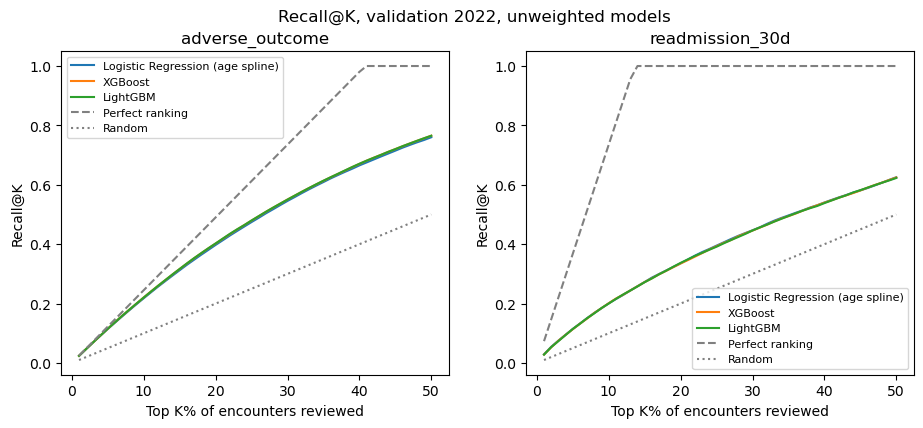

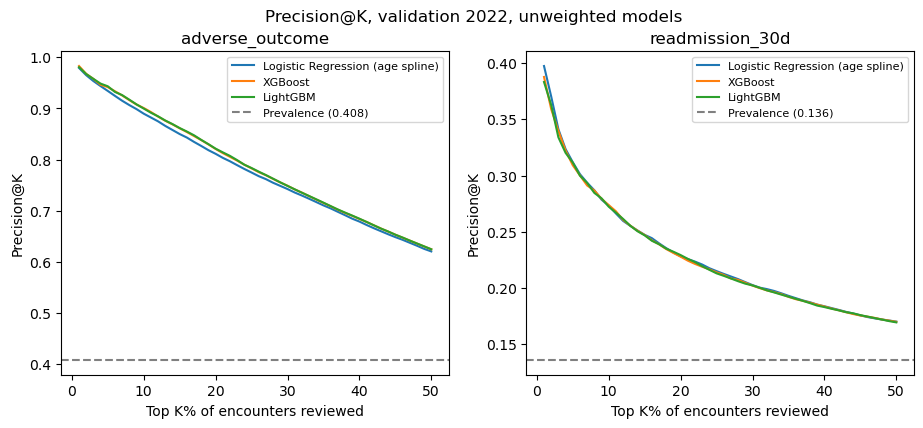

In [3]:
import matplotlib.pyplot as plt

tables = Path("../reports/tables"); tables.mkdir(parents=True, exist_ok=True)
figs = Path("../reports/figures"); figs.mkdir(parents=True, exist_ok=True)
fam_label = {"logreg": "Logistic Regression (age spline)", "xgboost": "XGBoost", "lightgbm": "LightGBM"}

wt.round(4).to_csv(tables / "imbalance_comparison.csv", index=False)

# ---- ranking table, unweighted models ----
parts = []
for t in targets:
    for fam in families:
        tbl = rank_table(val[t], wpreds[(fam, "none", t)], K_BY_TARGET[t])
        tbl.insert(0, "model", fam); tbl.insert(0, "target", t)
        parts.append(tbl)
rk = pd.concat(parts, ignore_index=True)
rk["max_recall"] = np.minimum(1.0, rk["n_review"] / rk["total_events"])
rk["recall_share_of_max"] = rk["recall"] / rk["max_recall"]
rk["f1"] = 2 * rk["precision"] * rk["recall"] / (rk["precision"] + rk["recall"])
rk["precision_ci_half"] = 1.96 * np.sqrt(rk["precision"] * (1 - rk["precision"]) / rk["n_review"])
rk.round(4).to_csv(tables / "ranking_capacity_results.csv", index=False)

show = ["K", "model", "events_captured", "false_positives", "recall", "recall_share_of_max",
        "precision", "precision_ci_half", "lift", "f1"]
for t in targets:
    print(t, "| prevalence", round(val[t].mean(), 4), "| events in val:", int(val[t].sum()))
    print(rk[rk["target"] == t][show].round(4).to_string(index=False))
    print()

# ---- figures ----
grid_k = np.round(np.arange(0.01, 0.51, 0.01), 2)
for metric, fname in [("recall", "recall_at_k.png"), ("precision", "precision_at_k.png")]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, t in zip(axes, targets):
        for fam, lab in fam_label.items():
            g = rank_table(val[t], wpreds[(fam, "none", t)], grid_k)
            ax.plot(g["K"] * 100, g[metric], label=lab)
        prev = val[t].mean()
        if metric == "recall":
            ax.plot(grid_k * 100, np.minimum(1, grid_k / prev), "--", color="grey", label="Perfect ranking")
            ax.plot(grid_k * 100, grid_k, ":", color="grey", label="Random")
        else:
            ax.axhline(prev, ls="--", color="grey", label=f"Prevalence ({prev:.3f})")
        ax.set_xlabel("Top K% of encounters reviewed")
        ax.set_ylabel(f"{metric.capitalize()}@K")
        ax.set_title(t); ax.legend(fontsize=8)
    fig.suptitle(f"{metric.capitalize()}@K, validation 2022, unweighted models")
    plt.savefig(figs / fname, dpi=150, bbox_inches="tight"); plt.show()

In [4]:
# drop the redundant column from the saved ranking file
rk.drop(columns=["recall_share_of_max"]).round(4).to_csv(tables / "ranking_capacity_results.csv", index=False)

# ---- selection evidence (unweighted models, val only) ----
none = wt[wt["weight"] == "none"].set_index(["target", "family"])
print(none[["pr_auc", "roc_auc", "brier", "ece", "trees", "secs"]].round(4).to_string())
print()
for t in targets:
    print(t)
    for a, b in [("xgboost", "lightgbm"), ("logreg", "lightgbm"), ("logreg", "xgboost")]:
        print(f"  {b} minus {a} [2.5%, median, 97.5%]:",
              paired_boot(val[t], wpreds[(a, "none", t)], wpreds[(b, "none", t)]))

# ---- save val predictions for Notebooks 05 to 07 (local only) ----
vp = val[["encounter_id"] + targets].copy()
vp["split"] = "val"
for t in targets:
    for fam in families:
        vp[f"{fam}_{t}"] = wpreds[(fam, "none", t)]
vp.to_parquet("../data/interim/val_predictions_classical.parquet", index=False)
print()
print("val predictions:", vp.shape, "| splits:", sorted(vp["split"].unique()))

for f in ["tables/imbalance_comparison.csv", "tables/ranking_capacity_results.csv",
          "figures/recall_at_k.png", "figures/precision_at_k.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

                          pr_auc  roc_auc   brier     ece  trees  secs
target          family                                                
adverse_outcome logreg    0.7464   0.7977  0.1768  0.0065    NaN     9
                xgboost   0.7548   0.8039  0.1741  0.0044  185.0    22
                lightgbm  0.7553   0.8041  0.1740  0.0043  291.0    10
readmission_30d logreg    0.2148   0.6085  0.1144  0.0029    NaN     7
                xgboost   0.2138   0.6080  0.1146  0.0067   36.0     9
                lightgbm  0.2138   0.6080  0.1145  0.0049   51.0     3

adverse_outcome
  lightgbm minus xgboost [2.5%, median, 97.5%]: [0.0001 0.0005 0.0008]
  lightgbm minus logreg [2.5%, median, 97.5%]: [0.0079 0.0088 0.01  ]
  xgboost minus logreg [2.5%, median, 97.5%]: [0.0073 0.0083 0.0095]
readmission_30d
  lightgbm minus xgboost [2.5%, median, 97.5%]: [-0.001 -0.     0.001]
  lightgbm minus logreg [2.5%, median, 97.5%]: [-0.0021 -0.0009  0.0004]
  xgboost minus logreg [2.5%, median, 97.5%]:

## Setup
Train on dev (2019 to 2021, 400,365 rows). Evaluate on val (2022, 133,853 rows). Holdout rows were filtered out when the file was read and never loaded. 90 features. Logistic Regression: age spline, median imputation, no indicators, C = 0.1. XGBoost and LightGBM: native NaN handling, early stopping on val PR-AUC. K values were fixed from prevalence before any result.

## Class weighting (reports/tables/imbalance_comparison.csv)
Weights: none (1), sqrt and full (the negative-to-positive ratio from dev: 1.44 for adverse_outcome, 6.26 for readmission_30d).
- adverse_outcome: PR-AUC moves by at most 0.0004 in any family. ECE rises with every step up in weight (Logistic Regression 0.0065, 0.0339, 0.0674).
- readmission_30d: PR-AUC is flat for Logistic Regression and XGBoost. Logistic Regression ECE goes 0.0029, 0.1442, 0.3491.
- LightGBM with weights on readmission_30d loses PR-AUC (0.2138, 0.2106, 0.2027, paired intervals exclude zero), but early stopping kept only 3 and 1 trees. The cause was not tested, so this is not a clean claim that weighting hurts.
- Decision: no class weighting for any model. It gave no ranking gain in any family and worsened probability quality.
- Resampling (SMOTE) was not run. readmission_30d is 13.6% prevalent, and weighting already gave no gain.
- The Brier and ECE columns in Notebook 03's reports/tables/model_comparison.csv come from class_weight="balanced" Logistic Regression and are inflated. Do not quote them. Calibration metrics come from Notebook 07.

## Ranking capacity (reports/tables/ranking_capacity_results.csv, unweighted models, val)
Cut-offs are top K% of encounters by predicted score. F1 here is computed at the top-K cut-off, not at a probability threshold.

adverse_outcome (54,615 events in val, prevalence 0.408), LightGBM:
- K = 5%: 6,313 events among 6,693 reviewed, precision 0.943, 380 false positives, lift 2.31 (ceiling 2.45).
- K = 40%: 36,641 events captured, recall 0.671, precision 0.684, 16,900 false positives. Random ranking would give recall 0.40.
- Boosted models beat Logistic Regression by about 60 events at K = 5% and 250 to 300 at K = 20 to 40%. XGBoost and LightGBM are within 30 events of each other at every K.

readmission_30d (18,209 events in val, prevalence 0.136), LightGBM:
- K = 10%: 3,645 events among 13,385 reviewed, recall 0.200, precision 0.272, lift 2.00.
- K = 20%: 6,139 events, recall 0.337, precision 0.229.
- The three families differ by under 40 events at every K. K = 1% (1,339 encounters, precision interval +/- 0.026) is too noisy to rank models on.

Risk ranking here is analytical prioritisation of a synthetic benchmark, not clinical decision support.

## Selected baseline (selected on val PR-AUC, ties broken by training time)
- adverse_outcome: LightGBM, PR-AUC 0.7553 (XGBoost 0.7548, difference +0.0005, interval 0.0001 to 0.0008). The tie rule was written after seeing these values, but LightGBM wins on PR-AUC and speed either way.
- readmission_30d: LightGBM, PR-AUC 0.2138, tied with XGBoost (0.2138) and Logistic Regression (0.2148). LightGBM minus Logistic Regression: -0.0021 to 0.0004.
- Logistic Regression stays as the interpretable reference in every later comparison.
- Val predictions for the three unweighted families are in data/interim/val_predictions_classical.parquet (local only).

## Limitations
- Early stopping on val makes boosted-model val scores slightly optimistic against Logistic Regression.
- The bootstrap measures sampling noise on val 2022 only, with one training seed.
- No hyperparameter search beyond early stopping.
- imbalance_comparison.csv is a new file not listed in the repository structure document. Add it to the README file list.

## Moves to Notebook 05
- Same dev and val, same 90 features, same metrics. Load data/interim/val_predictions_classical.parquet for paired comparisons against LightGBM and Logistic Regression.
- The MLP must beat LightGBM on val to be kept. Expect little room: boosted trees are 1% above Logistic Regression for adverse_outcome and tied for readmission_30d.
- Keep the experiment budget small. A rejected challenger is a valid result.